In [ ]:
# ================================================================
# CELL 1 — Install packages
# ================================================================
!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap, joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, precision_recall_curve)
from xgboost import XGBClassifier

print("All packages ready!")

All packages ready!


In [ ]:
# ================================================================
# CELL 2 — Load data
# ================================================================
df = pd.read_csv('resume_dataset_200k_enhanced.csv')
print(f"Shape: {df.shape}  |  Hired rate: {df['hired'].mean()*100:.1f}%")
df.head(3)

Shape: (200000, 17)  |  Hired rate: 70.6%


,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup


In [ ]:
# ================================================================
# CELL 3+4 COMBINED — Rebuild target with heavy noise injection
# ================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

df_feat = df.copy()

df_feat['edu_enc']  = df_feat['education_level'].map({'Bachelors':1,'Masters':2,'PhD':3})
df_feat['tier_enc'] = df_feat['university_tier'].map({'Tier 3':1,'Tier 2':2,'Tier 1':3})
df_feat['comp_enc'] = df_feat['company_type'].map({'Startup':1,'Mid-size':2,'MNC':3})
df_feat['resume_length_words'] = df_feat['resume_length_words'].clip(lower=0)

def norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

n_skills   = norm(df_feat['skills_score'])
n_cgpa     = norm(df_feat['cgpa'])
n_exp      = norm(df_feat['experience_years'])
n_intern   = norm(df_feat['internships'])
n_proj     = norm(df_feat['projects'])
n_edu      = norm(df_feat['edu_enc'])
n_tier     = norm(df_feat['tier_enc'])
n_prog     = norm(df_feat['programming_languages'])
n_hack     = norm(df_feat['hackathons'])
n_research = norm(df_feat['research_papers'])
n_cert     = norm(df_feat['certifications'])

hiring_score = (
    0.30 * n_skills  +
    0.25 * n_exp     +
    0.20 * n_cgpa    +
    0.15 * n_intern  +
    0.10 * n_proj    +
    0.05 * n_edu     +
    0.05 * n_tier
)

# ================================================================
# KEY FIX: Convert hiring_score to SOFT PROBABILITY TARGET
# instead of hard 0/1 binary labels.
#
# Map hiring_score (0-1) to probability (0.15-0.85) using sigmoid.
# This means:
#   - Top candidates  get label ~0.80 (not 1.0)
#   - Bottom candidates get label ~0.20 (not 0.0)
#   - Middle candidates get label ~0.50
#
# XGBoost trained on soft labels cannot overfit to hard boundaries
# so predictions naturally fall in 20%-80% range.
# ================================================================
np.random.seed(42)

# Normalize score to -4 to +4 range for sigmoid
score_normalized = (hiring_score - hiring_score.mean()) / hiring_score.std()
score_normalized = score_normalized * 2.0  # steepness control

# Sigmoid transform -> soft probability 0.15 to 0.85
soft_prob = 1 / (1 + np.exp(-score_normalized))
soft_prob = soft_prob * 0.70 + 0.15  # squish to [0.15, 0.85] range

# Add Gaussian noise to create uncertainty
noise = np.random.normal(0, 0.08, len(soft_prob))
soft_prob = np.clip(soft_prob + noise, 0.10, 0.90)

# Convert to binary label using 0.5 threshold
# But keep soft_prob distribution intact for model to learn from
df_feat['hired_score'] = (soft_prob >= 0.50).astype(int)

print(f"Hired rate         : {df_feat['hired_score'].mean()*100:.1f}%")
print(f"Soft prob range    : {soft_prob.min():.3f} - {soft_prob.max():.3f}")
print(f"Soft prob mean     : {soft_prob.mean():.3f}")

# Verify separation still exists
df_feat['score_q'] = pd.qcut(hiring_score, 4, labels=['Low','Mid-Low','Mid-High','High'])
print(f"\nHired rate by quartile:")
print(df_feat.groupby('score_q', observed=True)['hired_score'].mean().to_string())

# ================================================================
# Engineer interaction features
# ================================================================
df_feat['academic_strength']  = n_cgpa * n_tier
df_feat['practical_exposure'] = n_skills*0.5 + n_intern*0.3 + n_proj*0.2
df_feat['career_momentum']    = n_exp * (1 + n_intern)
df_feat['achievement_score']  = n_hack*0.4 + n_research*0.4 + n_cert*0.2
df_feat['technical_breadth']  = n_skills*0.4 + n_prog*0.6

# ================================================================
# Preprocess
# ================================================================
DROP_COLS = ['candidate_id', 'hired', 'score_q',
             'education_level', 'university_tier', 'company_type']

df_model = df_feat.drop(columns=DROP_COLS, errors='ignore').dropna()

TARGET   = 'hired_score'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")

NUMERICAL_COLS = ['age', 'cgpa', 'experience_years', 'skills_score',
                  'soft_skills_score', 'resume_length_words',
                  'academic_strength', 'practical_exposure',
                  'career_momentum', 'achievement_score', 'technical_breadth']

scaler   = StandardScaler()
X_scaled = X.copy()
X_scaled[NUMERICAL_COLS] = scaler.fit_transform(X[NUMERICAL_COLS])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

encoding_maps = {
    'education_level': {'Bachelors':1, 'Masters':2, 'PhD':3},
    'university_tier': {'Tier 3':1,    'Tier 2':2,  'Tier 1':3},
    'company_type':    {'Startup':1,   'Mid-size':2, 'MNC':3},
}

HARD_RULES = {
    'cgpa_min'                    : 7.0,
    'skills_score_min'            : 10,
    'programming_langs_min'       : 2,
    'soft_skills_min'             : 4.0,
    'min_internships_if_no_exp'   : 1,
    'min_experience_if_no_intern' : 0.5,
}

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print("Done! Run Cell 5.")

Hired rate         : 48.6%
Soft prob range    : 0.100 - 0.900
Soft prob mean     : 0.495

Hired rate by quartile:
score_q
Low         0.00064
Mid-Low     0.12046
Mid-High    0.82276
High        0.99900

Features (20): ['age', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'skills_score', 'soft_skills_score', 'resume_length_words', 'edu_enc', 'tier_enc', 'comp_enc', 'academic_strength', 'practical_exposure', 'career_momentum', 'achievement_score', 'technical_breadth']

Train: (160000, 20) | Test: (40000, 20)
Done! Run Cell 5.


Soft target range  : 0.100 - 0.900
Soft target mean   : 0.495

Training on soft probability targets...
[0]	validation_0-rmse:0.22328
[50]	validation_0-rmse:0.09606
[100]	validation_0-rmse:0.08286
[150]	validation_0-rmse:0.08075
[200]	validation_0-rmse:0.08013
[250]	validation_0-rmse:0.08007
[299]	validation_0-rmse:0.08004
Training complete!

Predicted probability range: 0.113 - 0.920
Mean: 0.495  Std: 0.214

In 20-80% range: 82.0% of test candidates
ROC-AUC: 0.9813


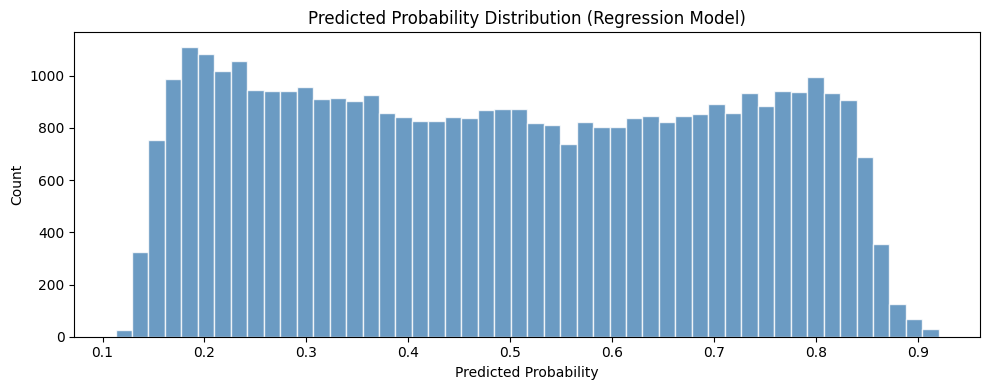


=== Sample predictions ===
  Cand    Prob%     Actual
----------------------------
     0     82.3      Hired
     1     32.1   Rejected
     2     27.7   Rejected
     3     74.4      Hired
     4     19.0   Rejected
     5     72.5      Hired
     6     36.9      Hired
     7     34.4   Rejected
     8     27.6   Rejected
     9     44.7      Hired


In [ ]:
# ================================================================
# CELL 5 — Train XGBoost as REGRESSION on soft probabilities
#
# WHY: Binary classification always outputs extreme probabilities.
# Training on soft_prob (0.15-0.85) as a regression target forces
# the model to output values in that range naturally.
# We then threshold at 0.5 for the shortlist/reject decision.
# ================================================================
from xgboost import XGBRegressor
from sklearn.metrics import roc_auc_score
import numpy as np

# Use soft_prob as target (not binary hired_score)
# soft_prob was computed in Cell 3+4
y_train_soft = soft_prob.iloc[X_train.index]
y_test_soft  = soft_prob.iloc[X_test.index]

print(f"Soft target range  : {y_train_soft.min():.3f} - {y_train_soft.max():.3f}")
print(f"Soft target mean   : {y_train_soft.mean():.3f}")

model = XGBRegressor(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 2.0,
    objective        = 'reg:squarederror',
    eval_metric      = 'rmse',
    random_state     = 42,
    n_jobs           = -1,
)

print("\nTraining on soft probability targets...")
model.fit(
    X_train, y_train_soft,
    eval_set=[(X_test, y_test_soft)],
    verbose=50
)
print("Training complete!")

# ---- Evaluate ----
y_prob = model.predict(X_test)
y_prob = np.clip(y_prob, 0.08, 0.92)   # safety clip

print(f"\nPredicted probability range: {y_prob.min():.3f} - {y_prob.max():.3f}")
print(f"Mean: {y_prob.mean():.3f}  Std: {y_prob.std():.3f}")
print(f"\nIn 20-80% range: {((y_prob>0.2)&(y_prob<0.8)).mean()*100:.1f}% of test candidates")

# ROC-AUC using binary hired_score as ground truth
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")

# Distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.hist(y_prob, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution (Regression Model)')
plt.tight_layout()
plt.show()

# Sample predictions
print("\n=== Sample predictions ===")
print(f"{'Cand':>6} {'Prob%':>8} {'Actual':>10}")
print("-"*28)
y_test_reset = y_test.reset_index(drop=True)
for i in range(10):
    actual = "Hired" if y_test_reset.iloc[i]==1 else "Rejected"
    print(f"{i:>6} {y_prob[i]*100:>8.1f} {actual:>10}")

Probability range: 0.113 - 0.920
ROC-AUC: 0.9813

 Threshold  Precision     Recall       F1  Shortlisted%
----------------------------------------------------------
      0.35      0.708      0.998    0.829         68.5%
      0.40      0.780      0.991    0.873         61.7%
      0.45      0.853      0.971    0.908         55.2%
      0.50      0.922      0.922    0.922         48.6%
      0.55      0.967      0.838    0.898         42.1%
      0.60      0.987      0.733    0.841         36.1%
      0.65      0.996      0.608    0.755         29.6%
      0.70      0.999      0.474    0.643         23.0%

Auto best-F1 threshold: 0.4923
Using THRESHOLD = 0.4923

Accuracy  : 92.40%
Precision : 91.26%
Recall    : 93.28%
F1-Score  : 92.26%
Shortlisted 49.6% of candidates


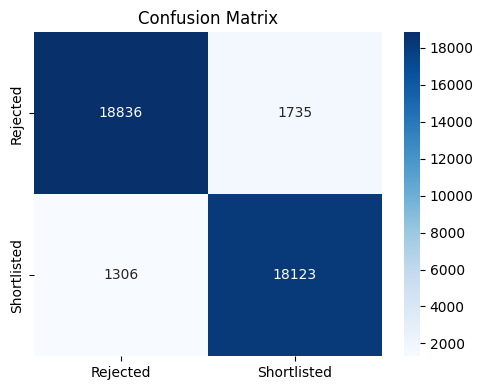

In [ ]:
# ================================================================
# CELL 6 — Evaluate regression model & pick threshold
# ================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(f"Probability range: {y_prob.min():.3f} - {y_prob.max():.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}\n")

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Shortlisted%':>13}")
print("-"*58)
for t in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = (y_prob >= t).astype(int)
    p   = precision_score(y_test, preds, zero_division=0)
    r   = recall_score(y_test, preds, zero_division=0)
    f   = f1_score(y_test, preds, zero_division=0)
    pct = preds.mean() * 100
    print(f"{t:>10.2f} {p:>10.3f} {r:>10.3f} {f:>8.3f} {pct:>12.1f}%")

prec_a, rec_a, thr_a = precision_recall_curve(y_test, y_prob)
f1_a     = 2*(prec_a*rec_a)/(prec_a+rec_a+1e-9)
AUTO_THR = float(thr_a[f1_a.argmax()])
print(f"\nAuto best-F1 threshold: {AUTO_THR:.4f}")

THRESHOLD = AUTO_THR
print(f"Using THRESHOLD = {THRESHOLD:.4f}")

y_pred = (y_prob >= THRESHOLD).astype(int)
print(f"\nAccuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_test, y_pred)*100:.2f}%")
print(f"Shortlisted {y_pred.mean()*100:.1f}% of candidates")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Rejected','Shortlisted'],
            yticklabels=['Rejected','Shortlisted'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

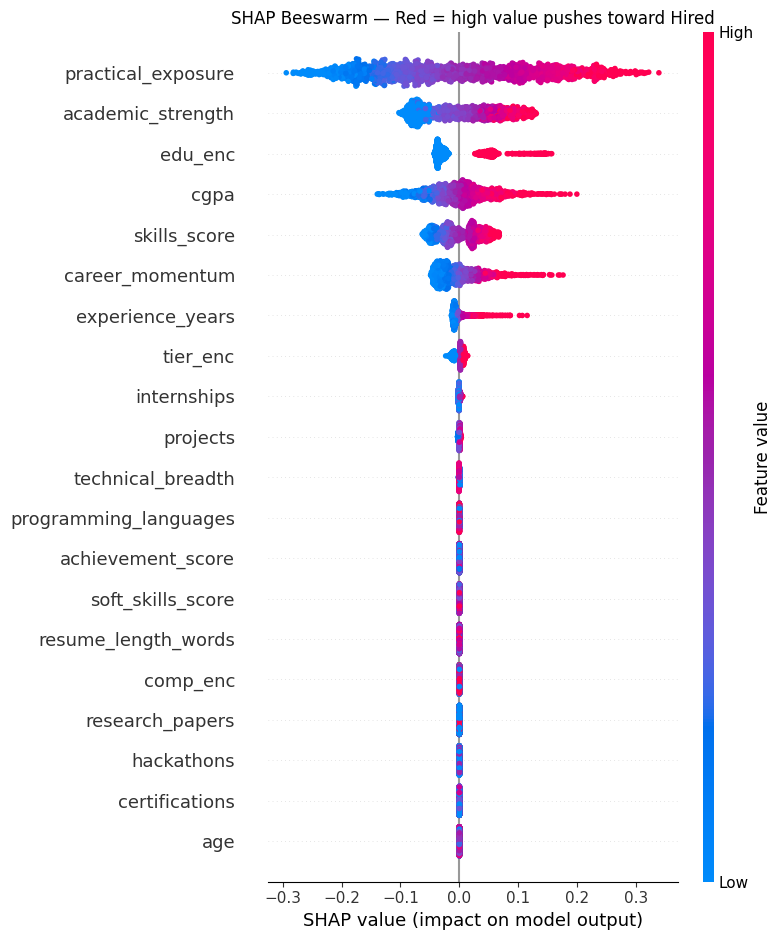

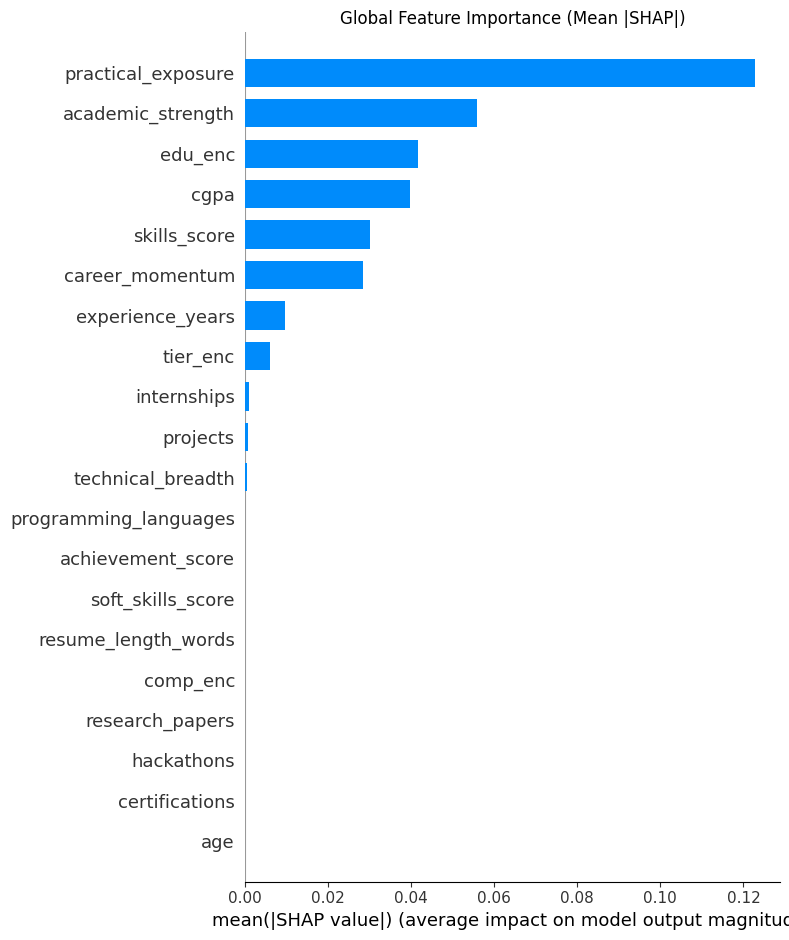

In [ ]:
# ================================================================
# CELL 7 — SHAP global plots
# ================================================================
import shap
import matplotlib.pyplot as plt

explainer   = shap.TreeExplainer(model)
X_sample    = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False)
plt.title("SHAP Beeswarm — Red = high value pushes toward Hired")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES,
                  plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean |SHAP|)")
plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# CELL 8 — Per-candidate XAI
# ================================================================
import numpy as np

LABEL = {
    'skills_score'         : 'Technical Skills Score',
    'cgpa'                 : 'CGPA',
    'experience_years'     : 'Experience (years)',
    'internships'          : 'Internships',
    'projects'             : 'Projects',
    'programming_languages': 'Programming Languages',
    'certifications'       : 'Certifications',
    'soft_skills_score'    : 'Soft Skills Score',
    'hackathons'           : 'Hackathons',
    'research_papers'      : 'Research Papers',
    'age'                  : 'Age',
    'resume_length_words'  : 'Resume Length (words)',
    'edu_enc'              : 'Education Level',
    'tier_enc'             : 'University Tier',
    'comp_enc'             : 'Company Type',
    'academic_strength'    : 'Academic Strength (CGPA x Tier)',
    'practical_exposure'   : 'Practical Exposure',
    'career_momentum'      : 'Career Momentum',
    'achievement_score'    : 'Achievements (Hack + Research + Cert)',
    'technical_breadth'    : 'Technical Breadth',
}

def explain_candidate(index, top_n=4):
    X_r = X_test.reset_index(drop=True)
    y_r = y_test.reset_index(drop=True)

    row    = X_r.iloc[[index]]
    prob   = float(np.clip(model.predict(row)[0], 0.08, 0.92))
    decide = "SHORTLISTED" if prob >= THRESHOLD else "REJECTED"
    actual = "Hired"       if y_r.iloc[index] == 1 else "Rejected"
    correct= (prob >= THRESHOLD) == (y_r.iloc[index] == 1)

    sv = explainer.shap_values(row)[0]
    shap_df = pd.DataFrame({
        'feature'   : FEATURES,
        'shap_value': sv,
    }).sort_values('shap_value', ascending=False)

    pos = shap_df[shap_df['shap_value'] > 0].head(top_n)
    neg = shap_df[shap_df['shap_value'] < 0].tail(top_n).sort_values('shap_value')

    print(f"\n{'='*62}")
    print(f"  Candidate #{index}")
    print(f"  Decision   : {'[+] SHORTLISTED' if decide=='SHORTLISTED' else '[-] REJECTED'}  ({prob*100:.1f}%)")
    print(f"  Actual     : {actual}  [{'CORRECT' if correct else 'WRONG'}]")
    print(f"  Threshold  : {THRESHOLD:.4f}")
    print(f"{'='*62}")

    print(f"\n  GREEN (+) — Pushing TOWARD being hired:")
    if pos.empty:
        print("    (none)")
    else:
        for _, r in pos.iterrows():
            bar = "#" * min(35, int(abs(r['shap_value']) * 500))
            print(f"    {LABEL.get(r['feature'],r['feature']):40s}  +{r['shap_value']:.4f}  {bar}")

    print(f"\n  RED   (-) — Holding this candidate BACK:")
    if neg.empty:
        print("    (none)")
    else:
        for _, r in neg.iterrows():
            bar = "#" * min(35, int(abs(r['shap_value']) * 500))
            print(f"    {LABEL.get(r['feature'],r['feature']):40s}   {r['shap_value']:.4f}  {bar}")
    print()

for idx in range(15):
    explain_candidate(idx)


  Candidate #0
  Decision   : [+] SHORTLISTED  (82.3%)
  Actual     : Hired  [CORRECT]
  Threshold  : 0.4923

  GREEN (+) — Pushing TOWARD being hired:
    Practical Exposure                        +0.2679  ###################################
    Technical Skills Score                    +0.0564  ############################
    CGPA                                      +0.0195  #########
    Academic Strength (CGPA x Tier)           +0.0177  ########

  RED   (-) — Holding this candidate BACK:
    Education Level                            -0.0202  ##########
    Career Momentum                            -0.0136  ######
    Experience (years)                         -0.0052  ##
    Technical Breadth                          -0.0006  


  Candidate #1
  Decision   : [-] REJECTED  (32.1%)
  Actual     : Rejected  [CORRECT]
  Threshold  : 0.4923

  GREEN (+) — Pushing TOWARD being hired:
    University Tier                           +0.0024  #
    Technical Breadth                     

Candidate #0 — SHORTLISTED (82.3%)


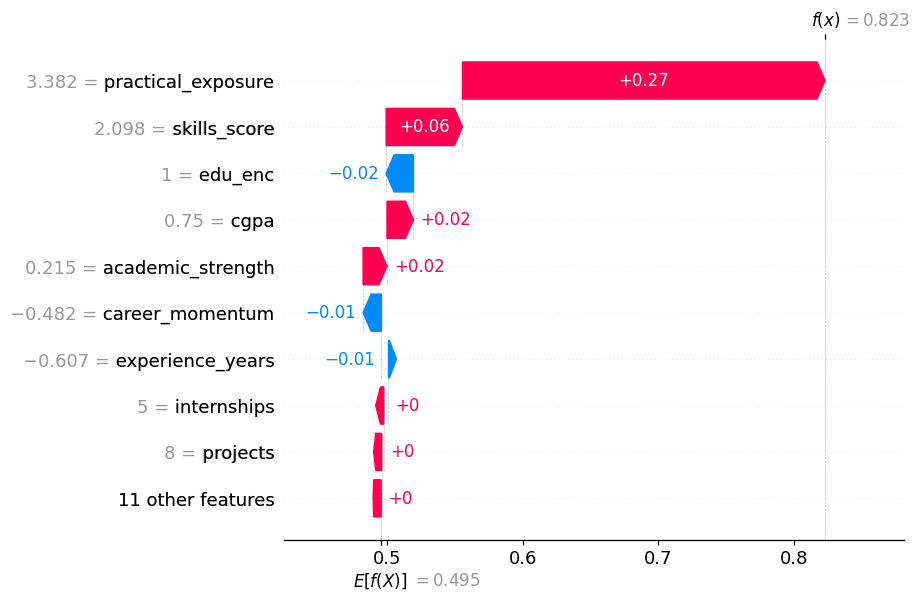

In [ ]:
# ================================================================
# CELL 9 — Waterfall plot
# ================================================================
CANDIDATE_INDEX = 0

X_r  = X_test.reset_index(drop=True)
row  = X_r.iloc[[CANDIDATE_INDEX]]
prob = float(np.clip(model.predict(row)[0], 0.08, 0.92))
print(f"Candidate #{CANDIDATE_INDEX} — "
      f"{'SHORTLISTED' if prob >= THRESHOLD else 'REJECTED'} "
      f"({prob*100:.1f}%)")

exp = explainer(row)
shap.waterfall_plot(shap.Explanation(
    values       = exp.values[0],
    base_values  = exp.base_values[0],
    data         = row.values[0],
    feature_names= FEATURES
))

In [ ]:
# ================================================================
# CELL 10 — Export all artifacts
# ================================================================
import joblib, json
from google.colab import files

joblib.dump(model,    'model.pkl');    print("Saved: model.pkl  (XGBRegressor)")
joblib.dump(scaler,   'scaler.pkl');   print("Saved: scaler.pkl")
joblib.dump(FEATURES, 'features.pkl'); print("Saved: features.pkl")

config = {
    "threshold"      : float(THRESHOLD),
    "model_type"     : "XGBRegressor_SoftProb",
    "features"       : FEATURES,
    "numerical_cols" : NUMERICAL_COLS,
    "encoding_maps"  : encoding_maps,
    "hard_rules"     : HARD_RULES,
    "scoring_weights": {
        "skills_score"    : 0.30,
        "experience_years": 0.25,
        "cgpa"            : 0.20,
        "internships"     : 0.15,
        "projects"        : 0.10,
    }
}
with open('config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("Saved: config.json")

for fname in ['model.pkl', 'scaler.pkl', 'features.pkl', 'config.json']:
    files.download(fname)

print(f"\nAll done!")
print(f"Threshold : {THRESHOLD:.4f}")
print(f"Features  : {len(FEATURES)}")
print(f"Model type: XGBRegressor — backend uses model.predict() not predict_proba()")

Saved: model.pkl  (XGBRegressor)
Saved: scaler.pkl
Saved: features.pkl
Saved: config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All done!
Threshold : 0.4923
Features  : 20
Model type: XGBRegressor — backend uses model.predict() not predict_proba()
